In [1]:
import sys
sys.path.append("/home/pwilmet/.local/lib/python3.11/site-packages/")
import pytoml

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import integrate
import sys
sys.path.append("../")


from nedflix.physics import Neutrino, InteractionType
from nedflix.conventions import units, Event
from nedflix.source import source_from_config
from nedflix.detector import detector_from_config
from nedflix.fun.sample_event import sample_events

In [3]:
plt.style.use("../paper.mplstyle")

Bad value in file '../paper.mplstyle', line 30 ('ytick.minor.width: &'): Key ytick.minor.width: Could not convert '&' to float


In [4]:
with open("../resources/configs/powerlaw_source_example.toml") as f:
    source_config = pytoml.load(f)
    source1 = source_from_config(source_config)
    source_config["location"]["right_ascension"] = 200
    source_config["location"]["declination"] = 45
    source2 = source_from_config(source_config)
    
with open("../resources/configs/example_detector.toml") as f:
    detector_config = pytoml.load(f)
    detector_config["response"]["detector_response_file"] = os.path.abspath("../" + detector_config["response"]["detector_response_file"])
    detector = detector_from_config(detector_config)

In [5]:
events1 = sample_events(detector, source1, 365*units.day)
events2 = sample_events(detector, source2, 365*units.day)

In [6]:
def is_track(event: Event) -> bool:
    if event.interaction!=InteractionType.ChargedCurrent:
        return False
    if event.initial_neutrino not in [Neutrino.NuMu, Neutrino.NuMuBar]:
        return False
    return True

In [7]:
def signal_flux(e, dec, nu, gamma=2.52, phi0=0.9e-18, eref=1e5*units.GeV):
    flux = phi0 * np.power(e / eref, -gamma)
    return flux

In [8]:
import sys
sys.path.append("/home/pwilmet/.local/lib/python3.11/site-packages/")
import nuflux

In [9]:
from nedflix.conventions.utils import sky_to_local
from nedflix.conventions.coordinates import SkyCoordinate,EarthCoordinate

In [10]:
def dec_to_zen(dec):
    d = SkyCoordinate(dec,5)
    x = EarthCoordinate(-np.pi/2,0)
    z = sky_to_local(sc=d, ec= x, t=4525)
    return z 

In [11]:
def background_flux(e, dec, nu):
    """
    zen = dec_to_zen(dec)
    c_z = np.cos(zen.zenith)
    """
    c_z = np.cos(np.pi/2 - dec)
    flux = nuflux.makeFlux('CORSIKA_GaisserH3a_SIBYLL-2.1')
    nu_type=nuflux.NuMu #Only tracks
    nu_energy=e*(10**(-9)) # in GeV
    nu_cos_zenith = c_z
    return flux.getFlux(nu_type,nu_energy,nu_cos_zenith)


In [12]:
from typing import Callable

In [13]:
def number_of_events(e: float, dec:float, signal=bool, spacing=10**0.5, tol=1e-4, hack=None):
    """Compute the signal-ness or background-ness.
    This is done by passing in a different `flux`.
    This is only done for track !

    params
    ______
    e: central energy
    dec: declination of interest
    nu: type of neutrino to calculate this for
    flux: function that computes flux at (e, dec, nu)
    [spacing]: width of the bin in which to calculate this quantity

    returns
    _______
    val: signalness or backgroundness
    """
    effa = detector.response.effective_area[(Neutrino.NuMu,InteractionType.ChargedCurrent)]
    
    if signal :
        def integrand(e):
            return effa(dec,e) * (signal_flux(e,dec,Neutrino.NuMu)+ signal_flux(e,dec, Neutrino.NuMuBar))
        #integrand = lambda x: effa(dec, x) * (signal_flux(x, dec, Neutrino.NuMu) + signal_flux(x, dec, Neutrino.NuMuBar))
    else :
        integrand = lambda x: effa(dec, x) * (background_flux(x, dec, Neutrino.NuMu) + background_flux(x, dec, Neutrino.NuMuBar))
        
    e_inf, e_sup = e / spacing, e * spacing

    if hack is None:
        hack = 1 / integrand(e)
        
    def int_helper(le):
        return hack * np.exp(le) * integrand(np.exp(le))
        
    val, err = integrate.quad(int_helper, np.log(e_inf), np.log(e_sup))
    if val==0:
        return val
    if err / val > tol:
        print(e, dec, signal, val, err)
        raise ValueError("Error too big. Ask Jeff about fixing this.")
    return val / hack

In [14]:
def signalness(e, dec, tol=1e-3):
    n_signal = number_of_events(e, dec, True, tol=tol)
    if n_signal==0:
        return 0.0
    n_bkg = number_of_events(e,dec,False, tol=tol)
    value = n_signal / (n_signal + n_bkg)
    return value

decs = np.sin(np.radians(np.arange(-90, 90, 5, dtype=float))) # doit être compris entre 
energie = 10**np.arange(12, 15, 0.1, dtype=float)#doit être sup à 2e11 #eV

sig = np.zeros((len(decs), len(energie)), dtype=float)
for idx,e in enumerate(tqdm(energie)): 
    for jdx,dec in enumerate(decs):
        sig[jdx,idx]= signalness(e, dec)

np.save("/data/user/pwilmet/signalness_fine.npy", sig)
#sig = np.load("/data/user/pwilmet/signalness_fine.npy")

In [ ]:
from tqdm import tqdm

/tmp/ipykernel_1332/775142761.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels([r"$10^{%d}$" % x for x in [-2, -1, 0]])


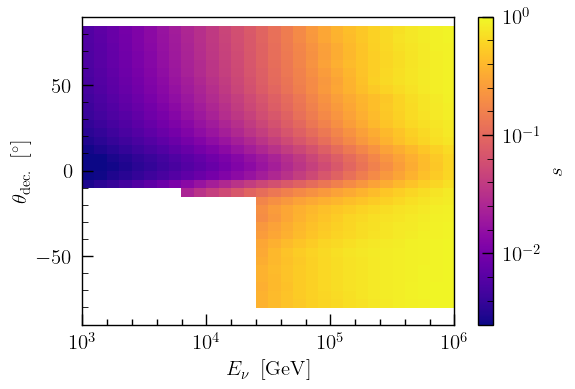

In [18]:
fig, ax = plt.subplots()

im = ax.imshow(
    #sig[::-1],
    np.log10(sig[::-1]),
    extent=[12-9, 15-9, -90, 90],
    aspect="auto",
    vmax=0.0,
    vmin=-2.6
)

ax.set_xlabel(r"$E_{\nu}~\left[\mathrm{GeV}\right]$")
ax.set_xticks([3, 4, 5, 6])
ax.set_xticklabels([r"$10^{%d}$" % x for x in [3, 4, 5, 6]])

ax.set_ylabel(r"$\theta_{\mathrm{dec.}}~\left[^{\circ}\right]$")

cbar = plt.colorbar(im, label=r"$s$")
cbar.set_ticklabels([r"$10^{%d}$" % x for x in [-2, -1, 0]])
cbar.set_ticks([-2, -1, 0])

plt.show()

In [32]:
#Création dataset 
#Il faut créer un dataframe avec les events et leurs caracts+ ajouter la signalness en fonction de ces caract
#On pourrait entrainer sur events1 et tester sur events2 
import pandas as pd
data_track= [{'reco_en': events1[i].reco_energy, 'reco_declination':getattr(events1[i].reco_direction,'declination'),
              'reco_ra':getattr(events1[i].reco_direction,'right_ascension')} for i in range(len(events1)) if is_track]
dataf = pd.DataFrame(data_track)
l_s =[]
for events in events1:
    l_s.append(sig(events.reco_energy, getattr(events.reco_direction,'declination')))
    
dataf['signalness'] = l_s

         reco_en  reco_declination   reco_ra
0   2.688834e+12          0.229367  0.765599
1   1.285192e+13          0.255143  0.653791
2   7.604582e+12          0.211521  0.951954
3   9.113779e+12          0.124875  0.826785
4   2.275308e+11          0.096088  0.851582
5   1.078186e+12          0.281166  0.949463
6   3.455170e+12         -0.080725  0.790536
7   1.472507e+12         -0.081278  0.817721
8   2.598126e+12          0.068248  0.640312
9   4.156595e+12          0.182364  0.835767
10  1.324953e+12         -0.174589  1.041994
11  7.869047e+11          0.128388  0.915246
12  3.120870e+12          0.177060  0.765636
13  2.239761e+12          0.230746  0.999868
14  1.140769e+12         -0.014320  0.683872
15  1.261954e+12         -0.021778  0.729530
16  7.002174e+13         -0.095312  0.800622
17  1.688434e+12          0.136847  0.997557


In [ ]:
##Conditions pour définir si c'est un signal + Ajout colonne signal

signal = []
for i in range(len(l_s)):
    if l_s[i] < 0.5:
        signal.append(0)
    else :
        signal.append(1)

dataf['Signal'] = signal
#Dataframe finit


In [ ]:
def background(dec,energie,nu,flux):
    for interaction in InteractionType: #Est ce que j'additionne les A_eff ? 
        integrand += detector.response.effective_area[(nu,interaction)](dec,energie)*flux
        borne_sup = energie*(10**0.5)
        borne_inf = energie/(10**0.5)
    integrale = integrate.quad(integrand,borne_sup,borne_inf)
    print(detector.response.effective_area[(nu,interaction)](dec,energie))
    return integrand

premier_cr = background(np.radians(60),2e11,Neutrino.NuMu,2.51384e-11)
#Prendre la dec associée
print(premier_cr)

In [ ]:
colors = ["crimson", "dodgerblue"]
for source, events, color in zip([source1, source2], [events1, events2], colors):
    decs, ras, is_tracks = [], [], []
    for event in events:
        decs = np.append(decs, event.reco_direction.declination)
        ras = np.append(ras, event.reco_direction.right_ascension)
        is_tracks = np.append(is_tracks, is_track(event)).astype(bool)

    plt.scatter(
        np.degrees(ras[~is_tracks]),
        np.degrees(decs[~is_tracks]),
        c=color,
        label="Cascades",
        alpha=0.3
    )
    plt.scatter(
        np.degrees(ras[is_tracks]),
        np.degrees(decs[is_tracks]),
        c=color,
        label="Tracks",
    )
    plt.scatter(
        np.degrees([source.location.right_ascension]),
        np.degrees([source.location.declination]),
        c="k",
        label="Source",
        marker="*"
    )

plt.xlim(0, 360)
plt.ylim(-90, 90)

plt.xlabel(r"Right ascension$~\left[^{\circ}\right]$")
plt.ylabel(r"Declination$~\left[^{\circ}\right]$")

plt.legend()

plt.show()